In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pickle
from scipy.signal import iirnotch, lfilter,freqz, iirfilter, find_peaks

**SE OBTIENE EL DATASET**




In [2]:
with open('dataset_ECG.pkl', 'rb') as f:
    ecg = pickle.load(f)

Fs = 1000
# A numpy
ecg_signal = np.concatenate(ecg['base'])
time = np.arange(0, len(ecg_signal)/Fs, 1/Fs)

# Funciones a usar
# Ploteo de datos
def plotear(array:np.ndarray,title:str,fs:int):
    Ts=1/fs
    n = np.arange(0,array.shape[0])  # t = n*Ts
    t = n*Ts
    plt.figure(figsize=(13,2))
    plt.title(title)
    plt.xlabel("Tiempo(s)")
    plt.plot(t, array)

# Transformada rápida de Fourier
def fftplot(signal:np.ndarray,fs):
    N = 2**10                                     # 10 bits, 0-1023

    signal_fft = np.fft.fft(signal, N)           # fft magtinud
    signal_fft = np.round(np.abs(signal_fft),3)[0:N//2] # nos quedamos con los componente de la derecha de la FFT
    signal_aux = signal_fft/signal_fft.max()     # hallamos el maximo para pasar la magnitud a escala db

    with np.errstate(divide='ignore'):
        signal_fft_db = 10*np.log10(signal_aux)  # , out=signal_aux, where=signal_aux >= 0 para evitar division por zero

    F_list = np.linspace(0,fs/2, N//2)
    F = np.round(F_list[np.argmax(signal_fft_db)], 1)   # argmax, encuentra el argumento max en un array

    plt.figure(figsize=(20,5))
    plt.plot(F_list, signal_fft_db)  #10 * np.log10(P / Pref) , decibelios
    plt.text(F,0, f"{F}Hz")
    plt.grid(linestyle=":")
    plt.ylabel("Magnitud (db)")
    plt.xlabel("Frecuencias (Hz)")
    plt.title("FFT en decibelios")
    plt.xlim([0,fs/2])
    plt.xticks(np.arange(0,fs/2,10))
    plt.show()

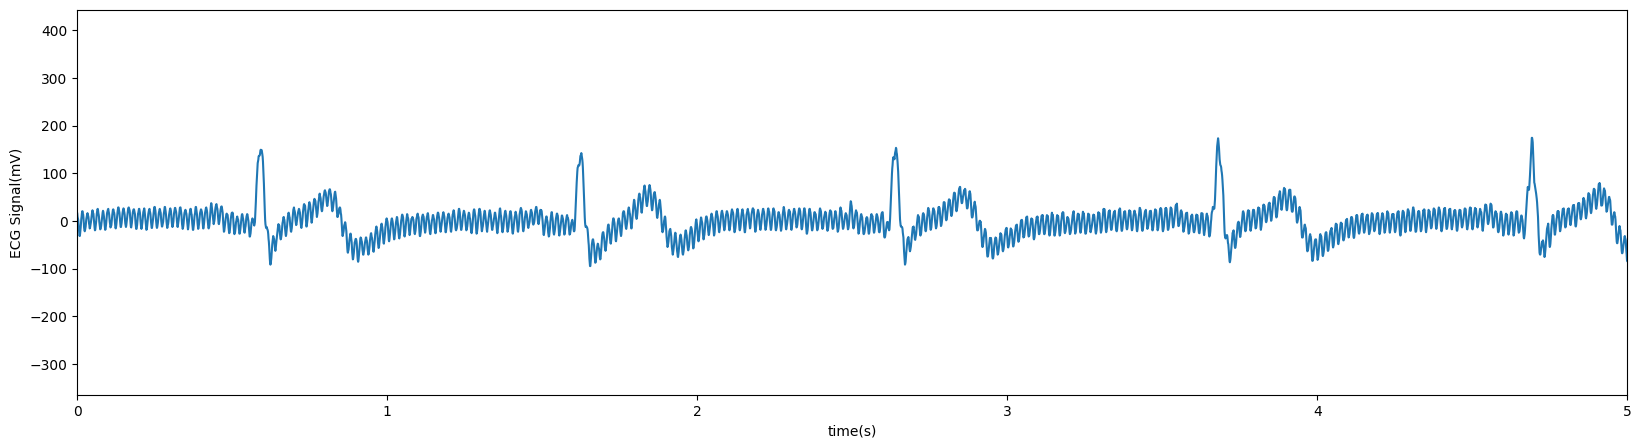

In [3]:
plt.figure(figsize=(20,5))
plt.plot(time,ecg_signal)
plt.ylabel('ECG Signal(mV)')
plt.xlabel('time(s)')
plt.xlim([0,5])
plt.show()

**SE ANALIZA LA SEÑAL EN FRECUENCIA**

Conociendo los datos de adquisición de la señal, analicemos ahora el espectro de Fourier.

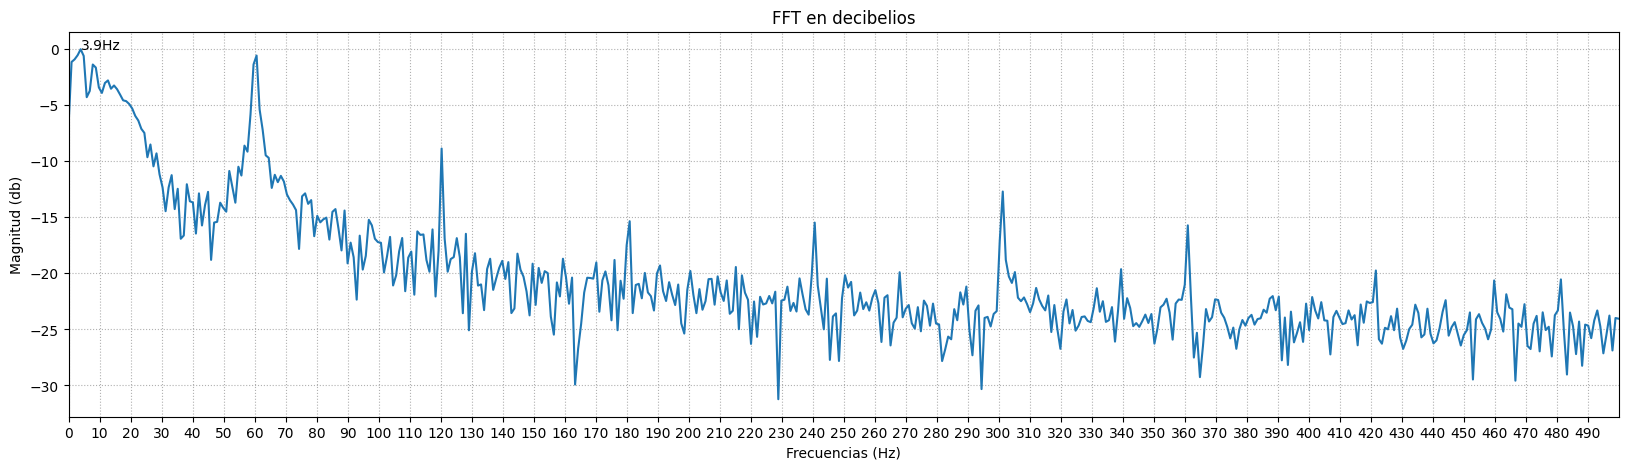

In [4]:
# Analizar el Fourier
fftplot(ecg_signal,Fs)

En el gráfico anterior, existe un ruido en 50 Hz y armónicos en 150 HZ. Por lo tanto, se debe filtrar.

Se propone utilizar filtros digitales Notch



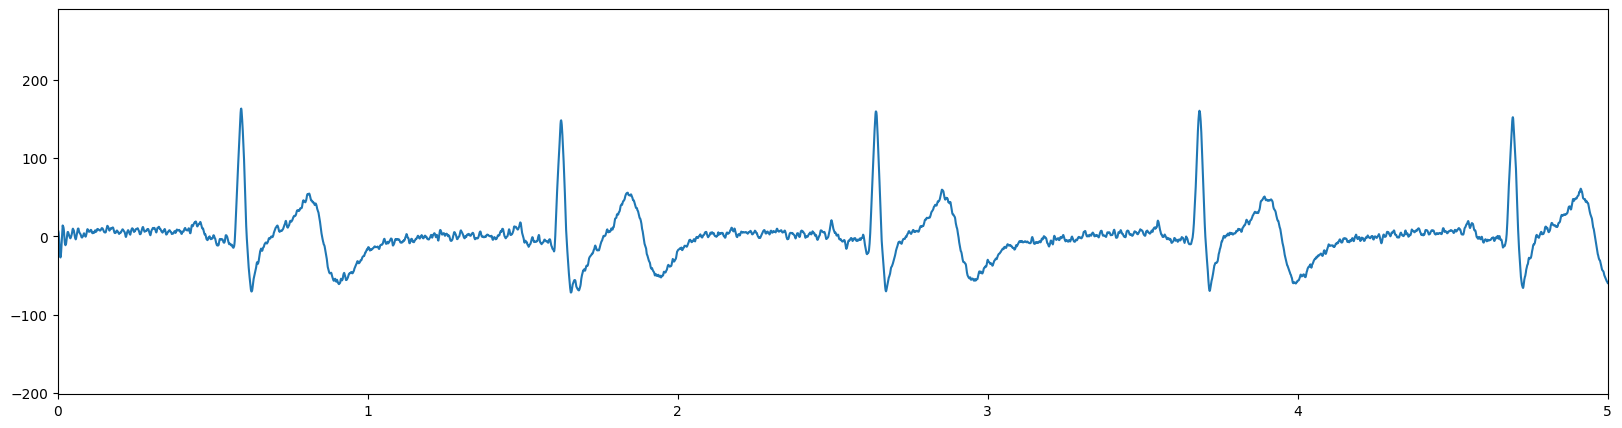

In [5]:
# Utilizar filtros Notch para quitar frecuencias que hagan ruido
f0 = 60.0  # Frecuencia que queremos filtrar (Hz)
Q = 20.0  # Factor de Calidad
# Diseño de filtro notch
b, a = iirnotch(f0, Q, Fs)
y = lfilter(b, a, ecg_signal)
y = lfilter(b, a, y)

for i in range(120, 481, 60):
    Q = 7.0  # Factor de Calidad
    # Diseño de filtro notch
    b, a = iirnotch(i, Q, Fs)
    y = lfilter(b,a,y)

plt.figure(figsize=(20,5))
plt.plot(time,y)
plt.xlim([0,5])
plt.show()

Regresamos a verificar las atenuaciones de los filtros en frecuencia

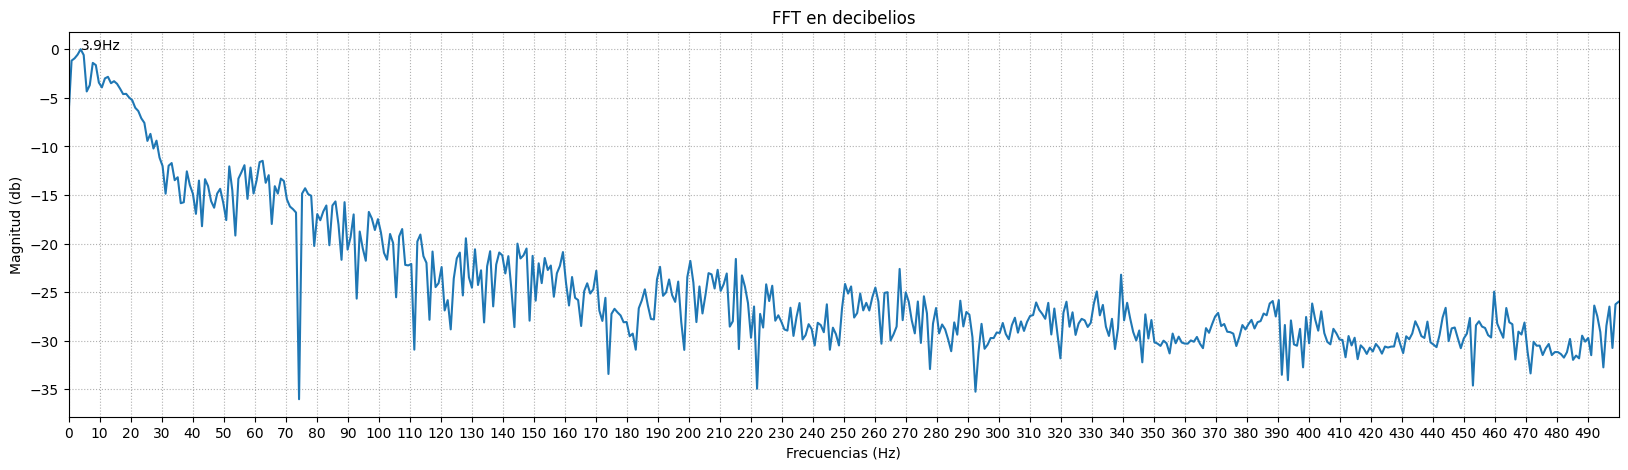

In [6]:
# Analisis de Fourier de los filtros
fftplot(y,Fs)

**FILTRADO DE PASA BANDA**

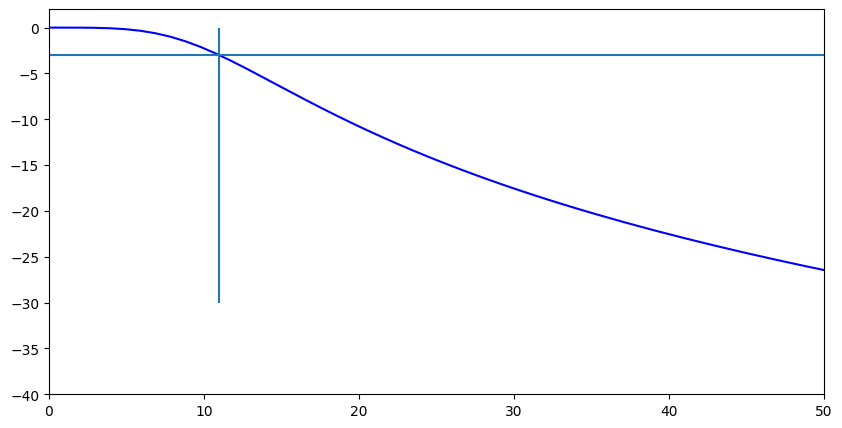

In [7]:
# 2. filtro pasa banda
# Sub filtro pasa bajo
b, a = iirfilter(2, 11.0, btype='lowpass', rs=3, ftype='butter', fs=Fs)
# TODO: 11?
w, h = freqz(b, a, fs=Fs)
plt.figure(figsize=(10,5))
plt.plot(w, 20 * np.log10(abs(h)), 'b')
plt.hlines(-3,0,250)
plt.xlim(0,50)
plt.vlines(11, -30, 0)
plt.ylim(-40,2)
plt.show()

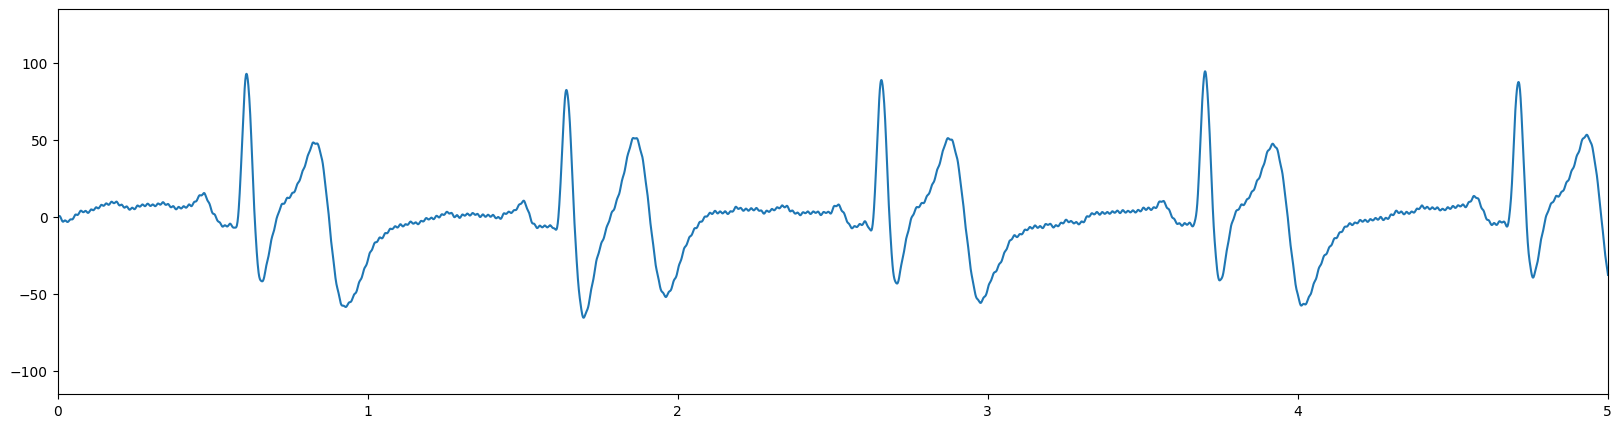

In [8]:
fpb_signal = lfilter(b, a, ecg_signal)
plt.figure(figsize=(20,5))
plt.plot(time,fpb_signal)
plt.xlim([0,5])
plt.show()

**FILTRO PASA ALTO**

C:\Users\USER\AppData\Local\Temp\ipykernel_9096\100304378.py:4: RuntimeWarning: divide by zero encountered in log10
  plt.plot(w, 20 * np.log10(abs(h)), 'b')


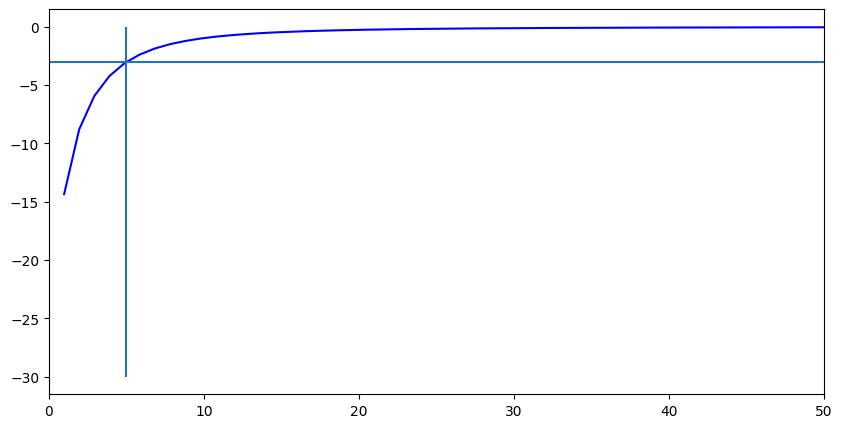

In [9]:
b, a = iirfilter(1, 5.0, btype='highpass', rs=3, ftype='butter', fs=Fs)
w, h = freqz(b, a, fs=Fs)
plt.figure(figsize=(10,5))
plt.plot(w, 20 * np.log10(abs(h)), 'b')
plt.hlines(-3,0,250)
plt.xlim(0,50)
plt.vlines(5, -30, 0)
plt.show()


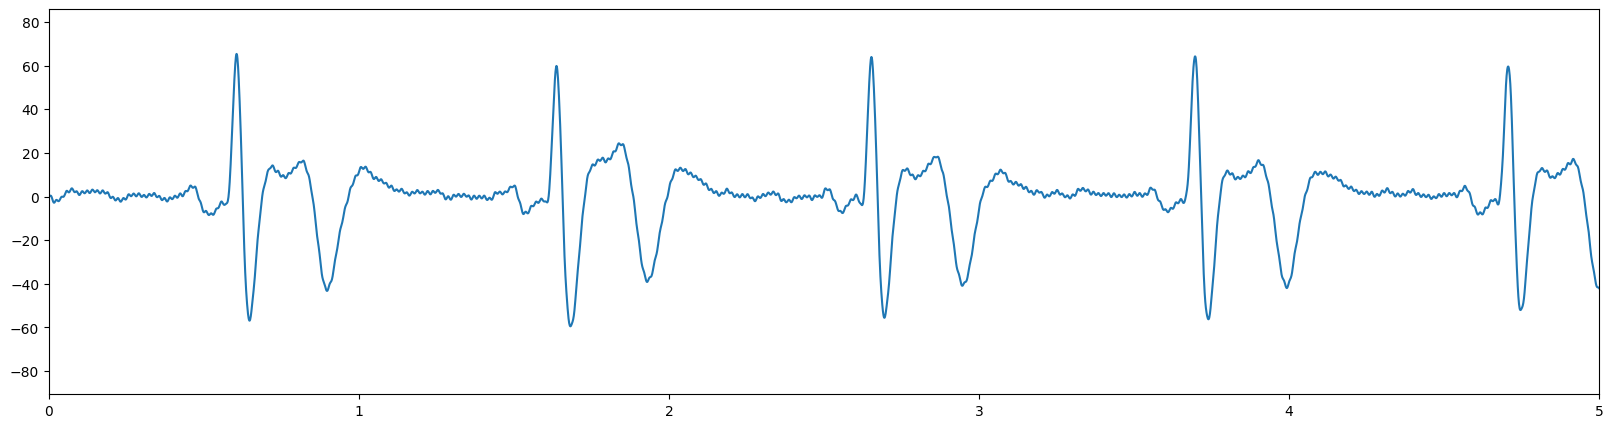

In [10]:
fpa_signal = lfilter(b, a, fpb_signal)
plt.figure(figsize=(20,5))
plt.plot(time,fpa_signal)
plt.xlim(0,5)
plt.show()

**OPERADOR DERIVATIVO**

En el artículo nos dan la siguiente función que describe al operador:

y[n]=(1/8)(−x[n−2]−2x[n−1]+2x[n+1]+x[n+2])

Para que esta ecuación pueda ser utilizada necesitamos encuadrarla en un rango de  [0,+∞]  haciendo que  n=+2  entonces tenemos:

y[n]=(1/8)(−x[n]−2x[n+1]+2x[n+3]+x[n+4]) 

Por lo tanto:

b=[−1,−2,0,2,1]

C:\Users\USER\AppData\Local\Temp\ipykernel_9096\1362607341.py:6: RuntimeWarning: divide by zero encountered in log10
  plt.plot(w, 20 * np.log10(abs(h)), 'b')


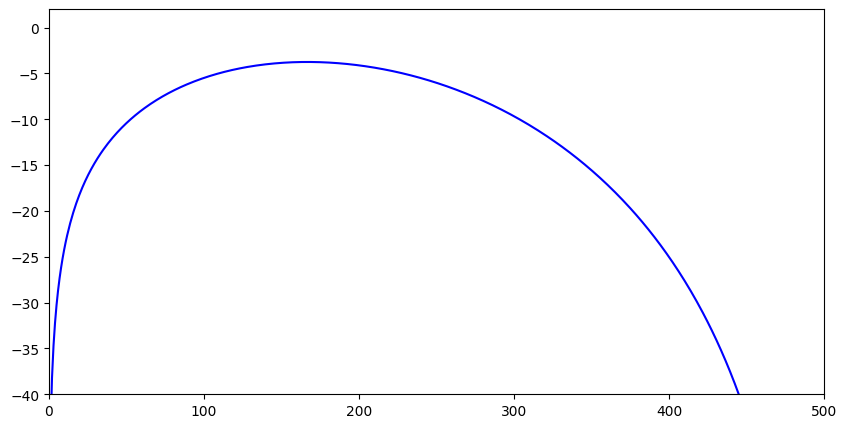

In [11]:
# Filtro derivativo
b = np.array([-1, -2, 0, 2, 1])
b = (1/8)*b
w, h = freqz(b, 1, fs=Fs)
plt.figure(figsize=(10,5))
plt.plot(w, 20 * np.log10(abs(h)), 'b')
plt.xlim(0,Fs/2)
plt.ylim(-40,2)
plt.show()

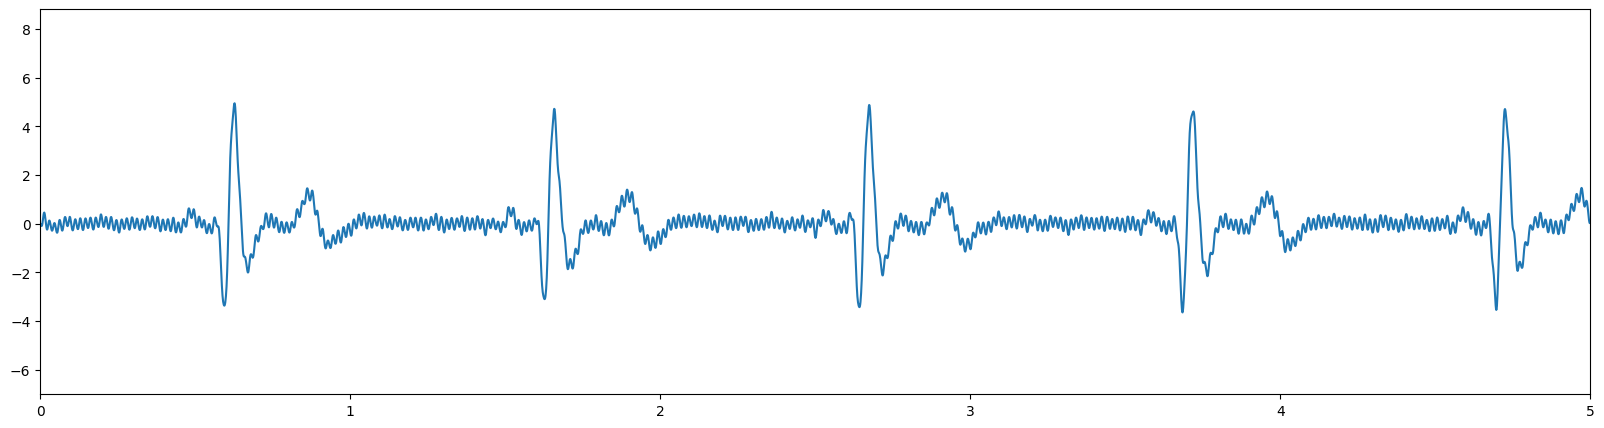

In [12]:
fd_signal = lfilter(b, 1, fpa_signal)
plt.figure(figsize=(20,5))
plt.plot(time,fd_signal)
plt.xlim(0,5)
plt.show()

**OPERADOR CUADRÁTICO**

Este operador solo tiene como función elevar al cuadrado los valores de la señal.

y[n]=x^2[n]

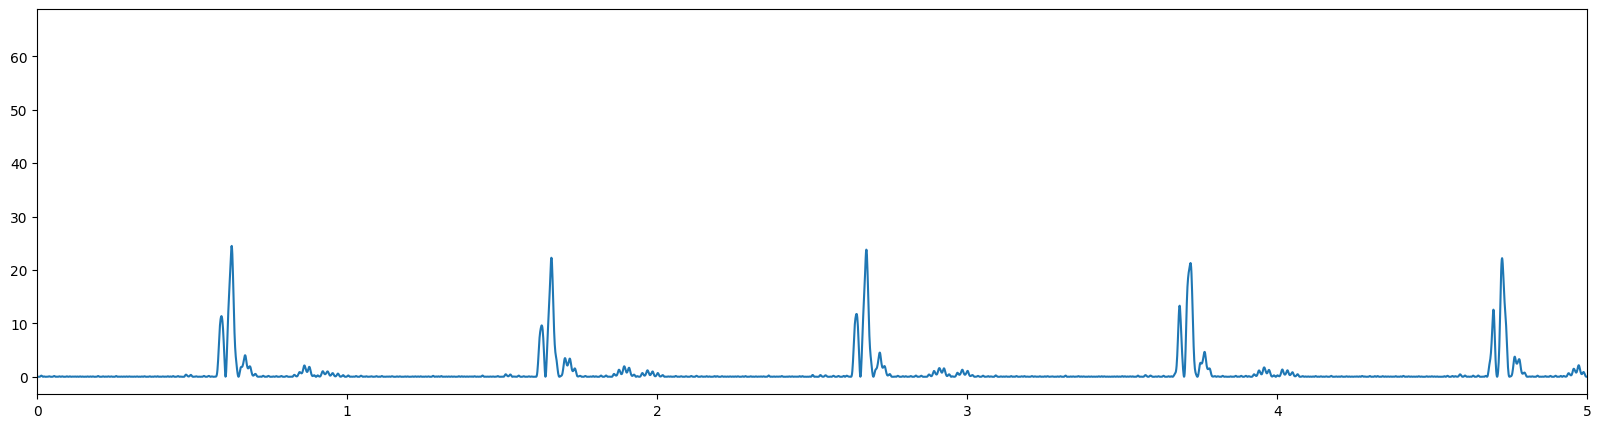

In [13]:
# Filtro cuadrado
f_sq = np.square(fd_signal)
plt.figure(figsize=(20,5))
plt.plot(time, f_sq)
plt.xlim(0,5)
plt.show()

**OPERADOR MOVING WINDOW INTEGRATION**

Este operador tiene como función extraer ciertas características de la onda.

y[n]=(1/N)(x[n−(N−1)]+x[n−(N−2)]+..+x[n])

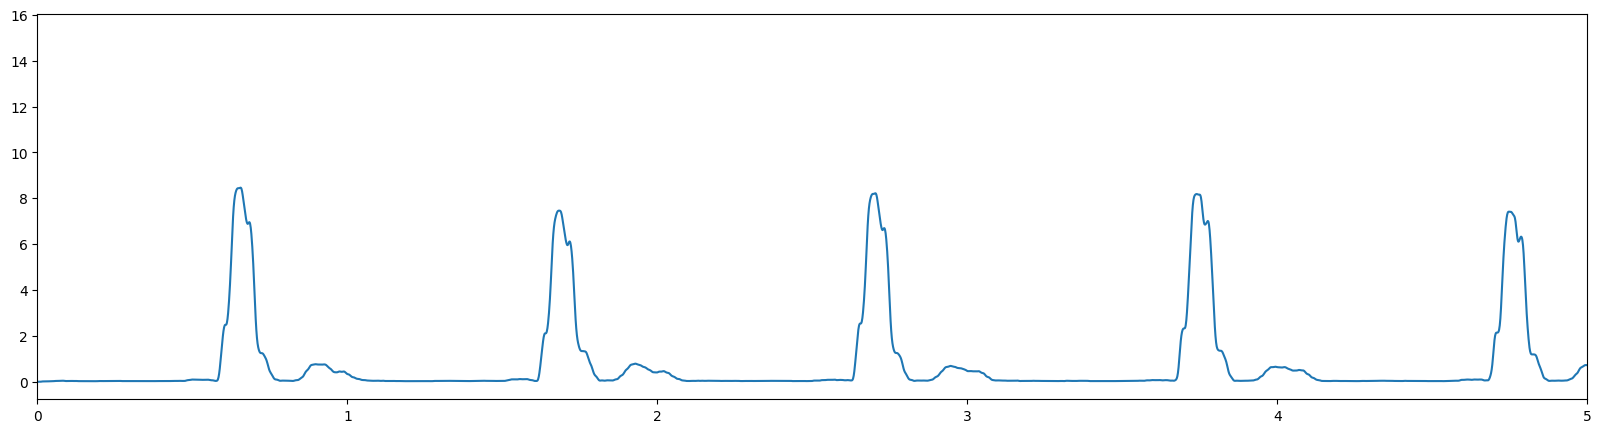

In [14]:
# Moving-Window Integration
N = 75
b = np.ones(N-1)
b = (1/N)*b
fi_signal = lfilter(b, 1, f_sq)
plt.figure(figsize=(20,5))
plt.plot(time,fi_signal)
plt.xlim(0,5)
plt.show()

Colocando marcadores en los picos

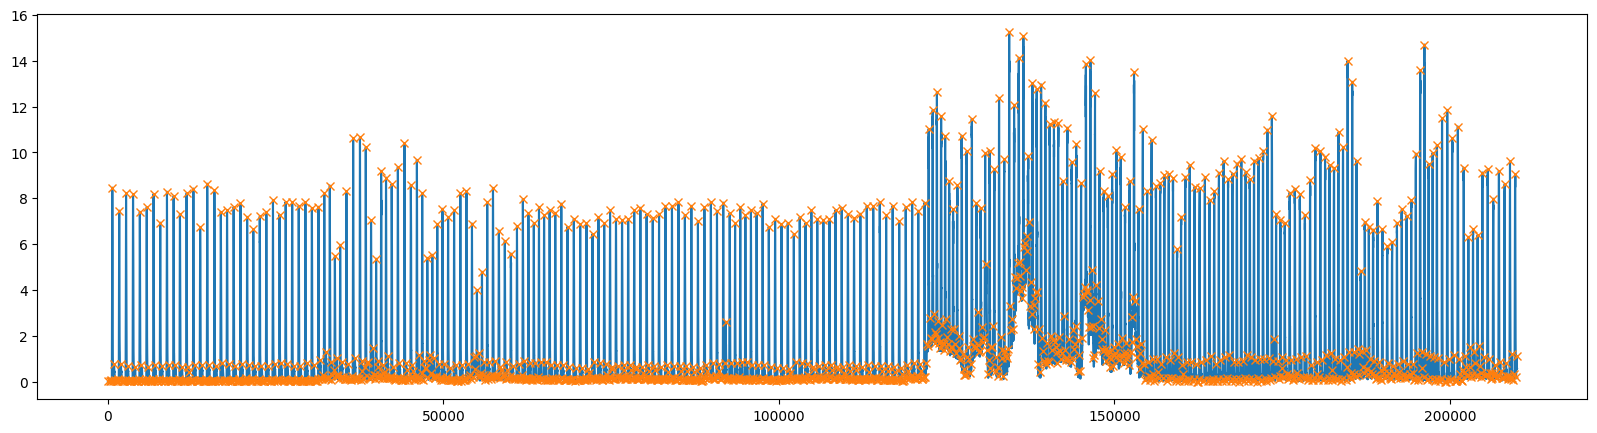

In [15]:
# Fiducial Marks
peaks, _ = find_peaks(fi_signal, distance=100)
plt.figure(figsize=(20,5))
plt.plot(fi_signal)
plt.plot(peaks, fi_signal[peaks], "x")
plt.show()

**ANÁLISIS DE THRESHOLD**

El valor del umbral de pico R de entrada es  3.8155764706241633
El valor del umbral de ruido de entrada es  0.9615231958107858


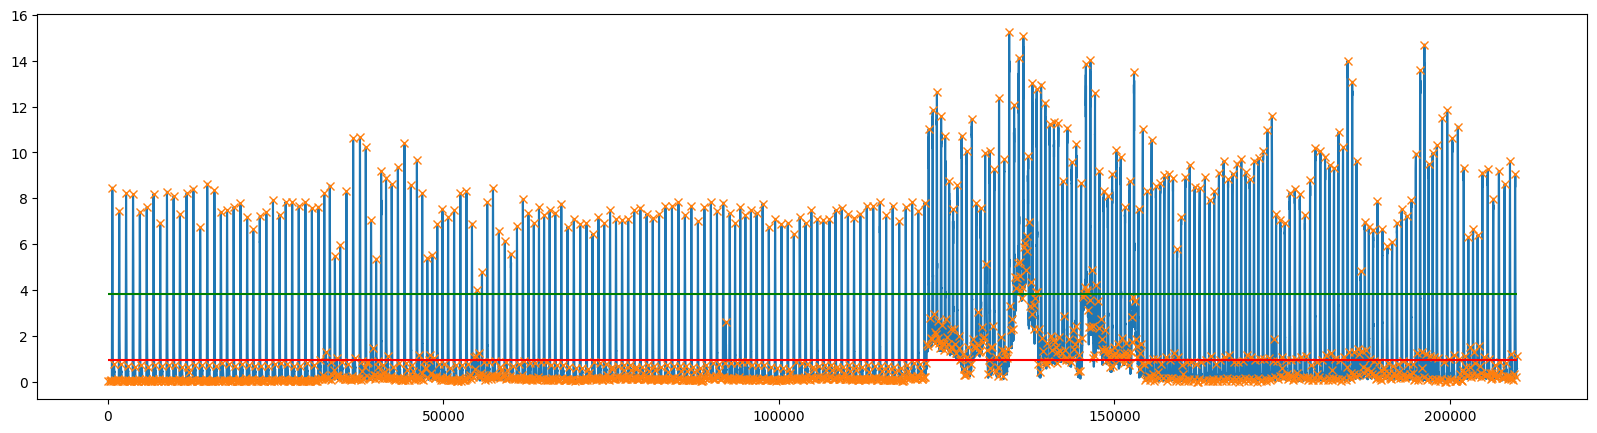

In [16]:
# Training Part to set Threshold I1 and Threshold I2
# Para las primeras muestras en 2 segundos
# Para efectos del ejercicio vamos a analizar toda la señal
f_samples = len(peaks)
th_I1 = np.max(fi_signal[peaks[:f_samples]])*0.25
th_I2 = 0.5*np.mean(fi_signal[peaks[:f_samples]])
print ("El valor del umbral de pico R de entrada es ", th_I1)
print ("El valor del umbral de ruido de entrada es ", th_I2)
plt.figure(figsize=(20,5))
plt.plot(fi_signal)
#plt.xlim(50,1000)
plt.plot(peaks, fi_signal[peaks], "x")
plt.hlines(th_I1, 0, len(fi_signal), colors='green')
plt.hlines(th_I2, 0, len(fi_signal), colors='red')
plt.show()

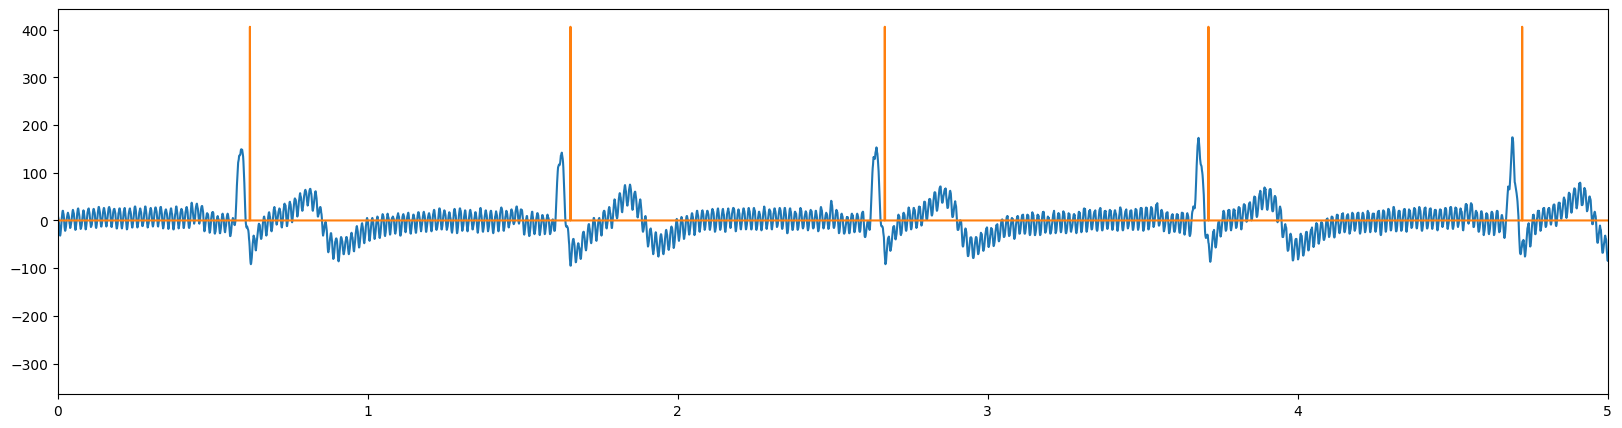

In [17]:
end_qrs = fi_signal > th_I1
roll_qrs_r = np.roll(end_qrs, 1)
roll_qrs_l = np.roll(end_qrs, -1)
end_qrs = np.logical_xor(end_qrs ,roll_qrs_r)
end_qrs = np.logical_and(end_qrs ,roll_qrs_l)
plt.figure(figsize=(20,5))
plt.plot(time,ecg_signal)
plt.plot(time,end_qrs*np.max(ecg_signal))
plt.xlim(0,5)
plt.show()

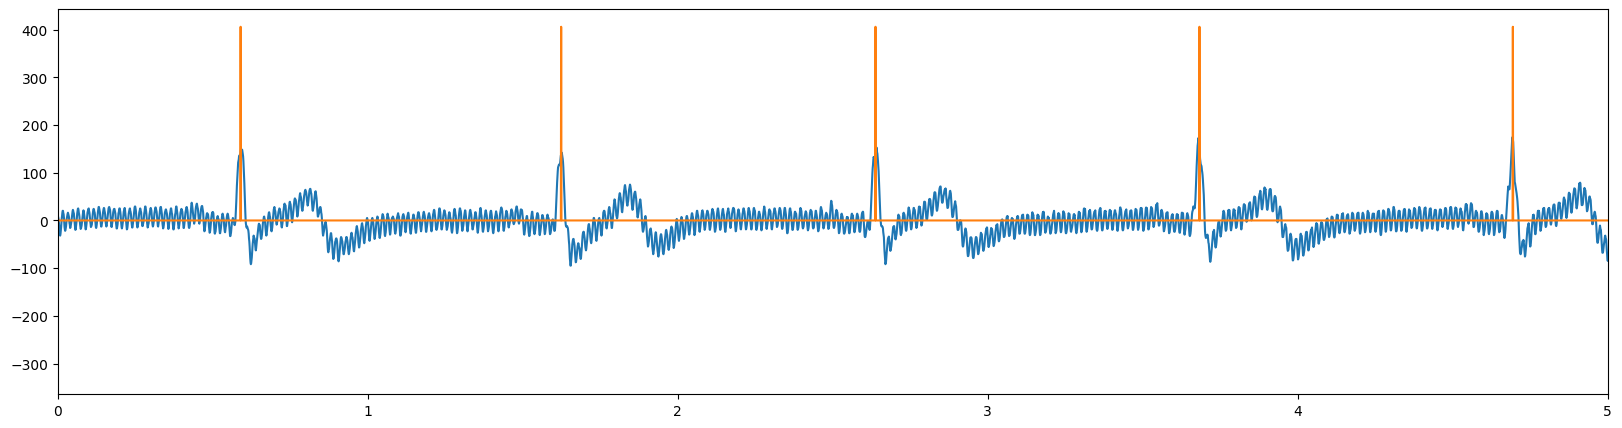

In [18]:
start_qrs = fi_signal < th_I2
roll_qrs_l = np.roll(start_qrs, -1)
roll_qrs_r = np.roll(start_qrs, 1)
start_qrs = np.logical_xor(start_qrs ,roll_qrs_l)
start_qrs = np.logical_and(start_qrs ,roll_qrs_r)
plt.figure(figsize=(20,5))
plt.plot(time,ecg_signal)
plt.plot(time,start_qrs*np.max(ecg_signal))
plt.xlim(0,5)
plt.show()

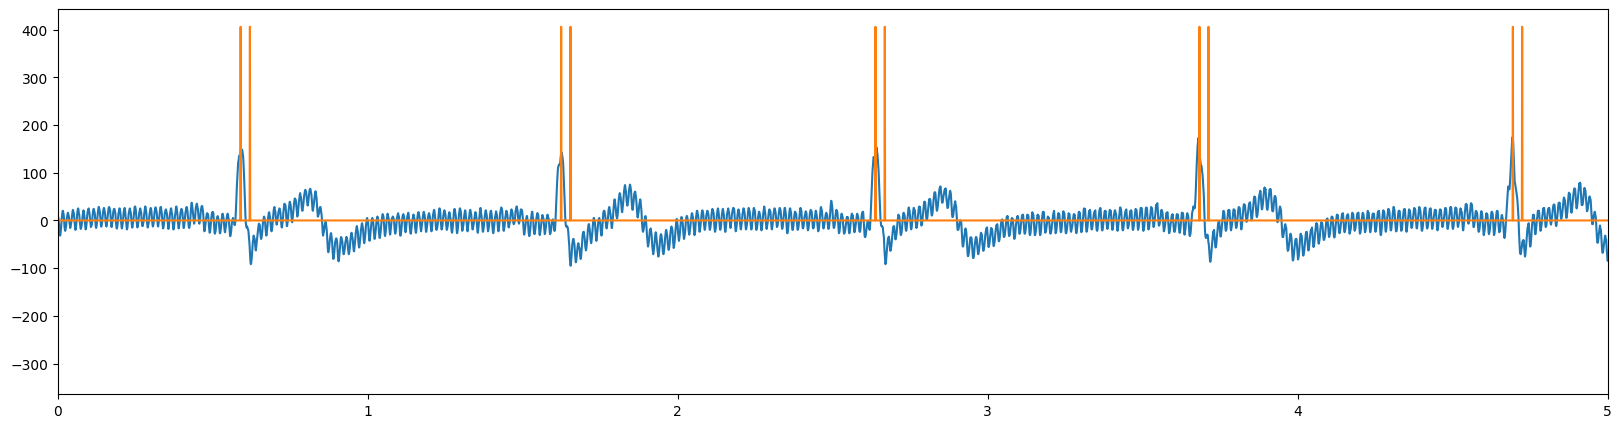

In [19]:
qrs = np.logical_or(start_qrs, end_qrs)
plt.figure(figsize=(20,5))
plt.plot(time,ecg_signal)
plt.plot(time,qrs*np.max(ecg_signal))
plt.xlim(0,5)
plt.show()


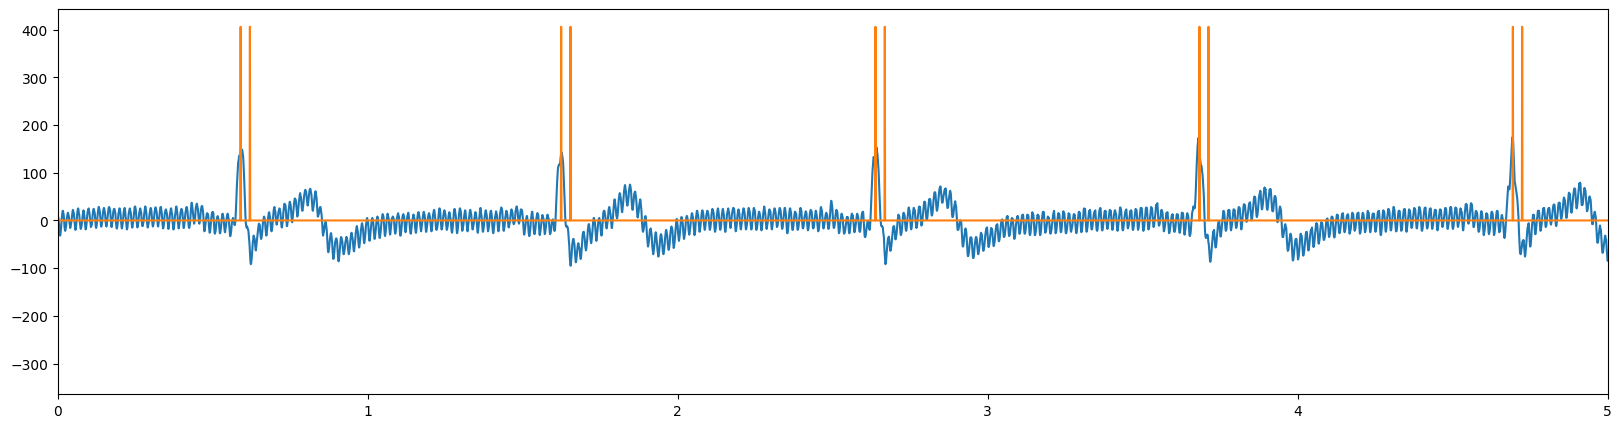

In [20]:
qrs = np.logical_or(start_qrs, end_qrs)
plt.figure(figsize=(20,5))
plt.plot(time,ecg_signal)
plt.plot(time,qrs*np.max(ecg_signal))
plt.xlim(0,5)
plt.show()